<a href="https://colab.research.google.com/github/souhaylelhammadi/Introduction-l-informatique-quantique/blob/main/TP1_Batch_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1 : Batch Gradient Descent (Descente de Gradient par Lot)

## Objectifs
- Comprendre le principe du **Batch Gradient Descent**
- Implémenter l'algorithme **from scratch** (sans librairies ML)
- Optimiser une fonction **simple** (quadratique) et une fonction **complexe** (Rosenbrock)
- Visualiser le **chemin de convergence** sur les contours de la fonction
- Appliquer le Batch GD à un problème de **classification** (régression logistique)
- Tracer les **courbes d'entraînement** et calculer les **métriques d'évaluation**

---

## 1. Théorie

### Principe
Le **Batch Gradient Descent** est la forme classique de la descente de gradient. À chaque itération, on calcule le gradient de la fonction de coût sur **l'ensemble complet** des données d'entraînement, puis on met à jour les paramètres :

$$\theta_{t+1} = \theta_t - \eta \cdot \nabla J(\theta_t)$$

où :
- $\theta_t$ : paramètres à l'itération $t$
- $\eta$ : taux d'apprentissage (learning rate)
- $\nabla J(\theta_t)$ : gradient de la fonction de coût évalué sur **tout** le dataset

### Avantages
- Convergence **stable** et **déterministe** (pas de bruit)
- Garantie de convergence vers un minimum local (pour $\eta$ suffisamment petit)

### Inconvénients
- **Lent** pour les grands datasets (calcul du gradient sur toutes les données)
- Peut rester bloqué dans des minima locaux
- Consomme beaucoup de **mémoire**

## 2. Imports et Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# Pour des figures plus jolies
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
np.random.seed(42)

## 3. Implémentation du Batch Gradient Descent

On implémente une version générique qui fonctionne avec n'importe quelle fonction et son gradient.

In [2]:
def batch_gradient_descent(gradient_func, x_init, learning_rate=0.01, n_iterations=1000, tol=1e-8):
    """
    Batch Gradient Descent générique.

    Paramètres:
    -----------
    gradient_func : callable
        Fonction qui retourne le gradient en un point donné
    x_init : np.array
        Point de départ
    learning_rate : float
        Taux d'apprentissage (eta)
    n_iterations : int
        Nombre maximum d'itérations
    tol : float
        Tolérance pour l'arrêt anticipé (norme du gradient)

    Retourne:
    ---------
    path : list of np.array
        Historique des positions visitées
    """
    x = np.array(x_init, dtype=float)
    path = [x.copy()]

    for i in range(n_iterations):
        # Calcul du gradient au point courant
        grad = gradient_func(x)

        # Critère d'arrêt : si le gradient est très petit, on a convergé
        if np.linalg.norm(grad) < tol:
            print(f"Convergence atteinte à l'itération {i}")
            break

        # Mise à jour des paramètres : x = x - eta * gradient
        x = x - learning_rate * grad

        # Sauvegarde du chemin
        path.append(x.copy())

    return path

## 4. Fonction Simple : Fonction Quadratique

$$f(x, y) = x^2 + y^2$$

C'est une fonction convexe avec un **minimum global** en $(0, 0)$.

Le gradient est :
$$\nabla f(x, y) = \begin{pmatrix} 2x \\ 2y \end{pmatrix}$$

In [3]:
# Définition de la fonction et de son gradient
def f_simple(x):
    """f(x, y) = x^2 + y^2"""
    return x[0]**2 + x[1]**2

def grad_simple(x):
    """Gradient de f(x, y) = x^2 + y^2"""
    return np.array([2*x[0], 2*x[1]])

In [4]:
# Exécution du Batch Gradient Descent
x_init = np.array([4.0, 3.0])  # Point de départ
path_simple = batch_gradient_descent(grad_simple, x_init, learning_rate=0.1, n_iterations=100)

print(f"Point de départ  : {path_simple[0]}")
print(f"Point d'arrivée  : {path_simple[-1]}")
print(f"Nombre d'itérations : {len(path_simple) - 1}")
print(f"Valeur finale de f  : {f_simple(path_simple[-1]):.10f}")

Convergence atteinte à l'itération 93
Point de départ  : [4. 3.]
Point d'arrivée  : [3.88533778e-09 2.91400334e-09]
Nombre d'itérations : 93
Valeur finale de f  : 0.0000000000


### Visualisation du chemin de convergence

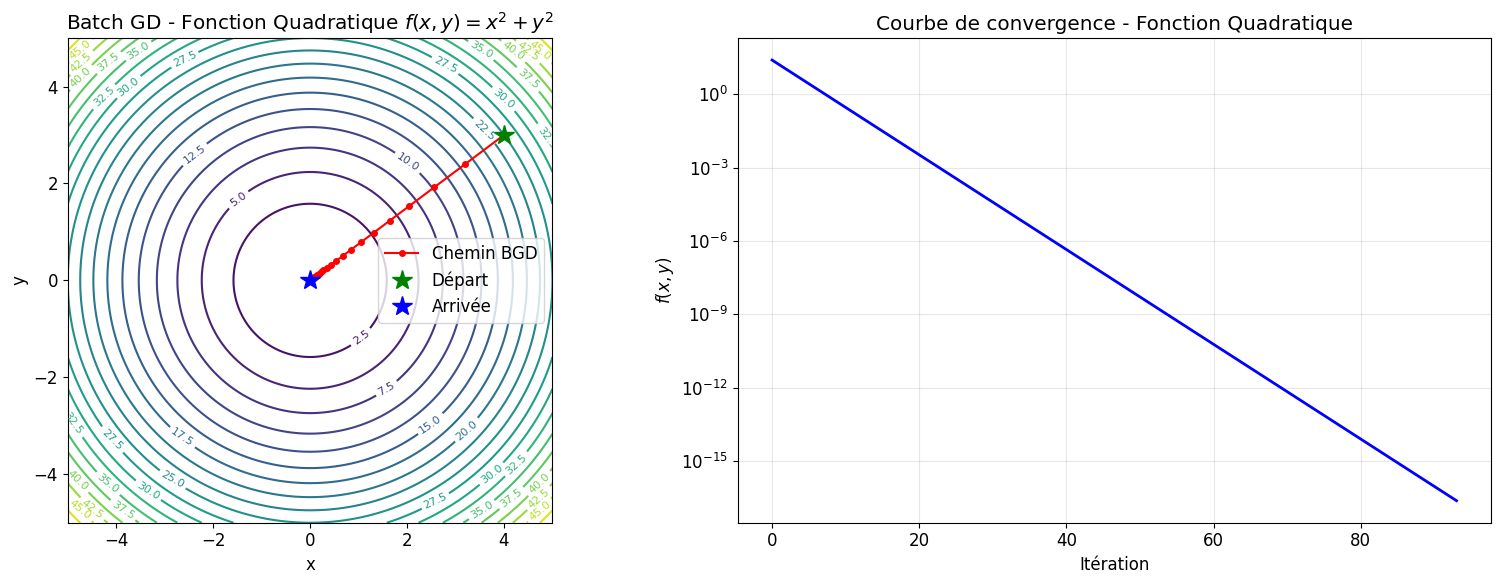

In [5]:
# Création de la grille pour les contours
x_range = np.linspace(-5, 5, 200)
y_range = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x_range, y_range)
Z = X**2 + Y**2

# Extraction du chemin
path_arr = np.array(path_simple)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Figure 1 : Contour plot avec chemin ---
ax1 = axes[0]
contour = ax1.contour(X, Y, Z, levels=20, cmap='viridis')
ax1.clabel(contour, inline=True, fontsize=8)
ax1.plot(path_arr[:, 0], path_arr[:, 1], 'ro-', markersize=4, linewidth=1.5, label='Chemin BGD')
ax1.plot(path_arr[0, 0], path_arr[0, 1], 'g*', markersize=15, label='Départ')
ax1.plot(path_arr[-1, 0], path_arr[-1, 1], 'b*', markersize=15, label='Arrivée')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Batch GD - Fonction Quadratique $f(x,y) = x^2 + y^2$')
ax1.legend()
ax1.set_aspect('equal')

# --- Figure 2 : Courbe de la valeur de f au fil des itérations ---
ax2 = axes[1]
f_values = [f_simple(p) for p in path_simple]
ax2.plot(f_values, 'b-', linewidth=2)
ax2.set_xlabel('Itération')
ax2.set_ylabel('$f(x, y)$')
ax2.set_title('Courbe de convergence - Fonction Quadratique')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Surface 3D de la fonction simple

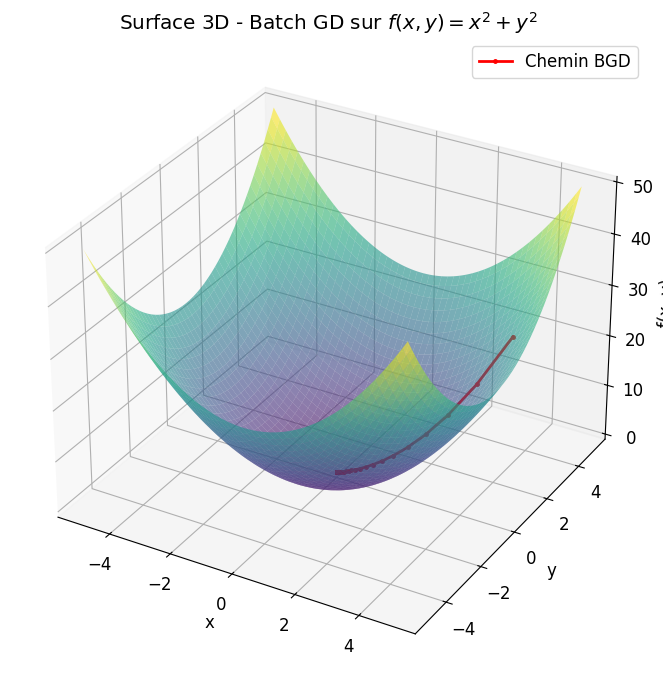

In [6]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Surface
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6, edgecolor='none')

# Chemin de descente en 3D
z_path = [f_simple(p) for p in path_simple]
ax.plot(path_arr[:, 0], path_arr[:, 1], z_path, 'r.-', markersize=5, linewidth=2, label='Chemin BGD')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.set_title('Surface 3D - Batch GD sur $f(x,y) = x^2 + y^2$')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Fonction Complexe : Fonction de Rosenbrock

$$f(x, y) = (1 - x)^2 + 100(y - x^2)^2$$

Cette fonction est connue pour être **difficile à optimiser** :
- Le minimum global est en $(1, 1)$ avec $f(1,1) = 0$
- Elle possède une **vallée étroite et courbe** qui rend la convergence lente

Le gradient est :
$$\nabla f(x, y) = \begin{pmatrix} -2(1-x) - 400x(y - x^2) \\ 200(y - x^2) \end{pmatrix}$$

In [7]:
def f_rosenbrock(x):
    """Fonction de Rosenbrock : f(x,y) = (1-x)^2 + 100*(y-x^2)^2"""
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

def grad_rosenbrock(x):
    """Gradient de la fonction de Rosenbrock"""
    dfdx = -2 * (1 - x[0]) - 400 * x[0] * (x[1] - x[0]**2)
    dfdy = 200 * (x[1] - x[0]**2)
    return np.array([dfdx, dfdy])

In [8]:
# Exécution - attention au learning rate, la Rosenbrock nécessite un lr très petit
x_init_rosen = np.array([-1.5, 1.5])
path_rosen = batch_gradient_descent(grad_rosenbrock, x_init_rosen, learning_rate=0.001, n_iterations=10000)

print(f"Point de départ  : {path_rosen[0]}")
print(f"Point d'arrivée  : {path_rosen[-1]}")
print(f"Minimum attendu  : [1.0, 1.0]")
print(f"Nombre d'itérations : {len(path_rosen) - 1}")
print(f"Valeur finale de f  : {f_rosenbrock(path_rosen[-1]):.8f}")

Point de départ  : [-1.5  1.5]
Point d'arrivée  : [0.99133699 0.98271418]
Minimum attendu  : [1.0, 1.0]
Nombre d'itérations : 10000
Valeur finale de f  : 0.00007517


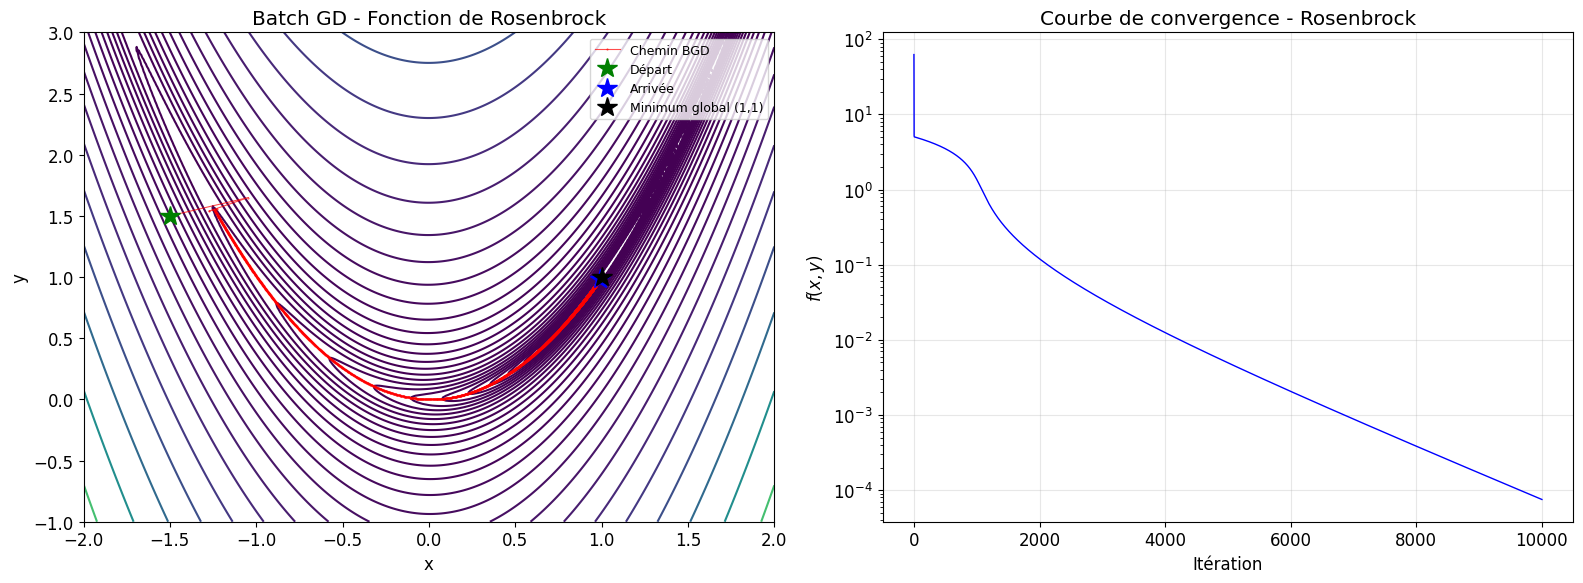

In [9]:
# Visualisation de la convergence sur la Rosenbrock
x_range_r = np.linspace(-2, 2, 300)
y_range_r = np.linspace(-1, 3, 300)
Xr, Yr = np.meshgrid(x_range_r, y_range_r)
Zr = (1 - Xr)**2 + 100 * (Yr - Xr**2)**2

path_arr_r = np.array(path_rosen)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Contour plot ---
ax1 = axes[0]
# On utilise des niveaux logarithmiques pour mieux voir la vallée
levels = np.logspace(-1, 3.5, 30)
contour = ax1.contour(Xr, Yr, Zr, levels=levels, cmap='viridis')
ax1.plot(path_arr_r[:, 0], path_arr_r[:, 1], 'r.-', markersize=1, linewidth=0.8, alpha=0.7, label='Chemin BGD')
ax1.plot(path_arr_r[0, 0], path_arr_r[0, 1], 'g*', markersize=15, label='Départ')
ax1.plot(path_arr_r[-1, 0], path_arr_r[-1, 1], 'b*', markersize=15, label='Arrivée')
ax1.plot(1, 1, 'k*', markersize=15, label='Minimum global (1,1)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Batch GD - Fonction de Rosenbrock')
ax1.legend(fontsize=9)

# --- Courbe de convergence ---
ax2 = axes[1]
f_values_r = [f_rosenbrock(p) for p in path_rosen]
ax2.plot(f_values_r, 'b-', linewidth=1)
ax2.set_xlabel('Itération')
ax2.set_ylabel('$f(x, y)$')
ax2.set_title('Courbe de convergence - Rosenbrock')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Effet du Learning Rate

Le choix du taux d'apprentissage est **crucial**. Testons plusieurs valeurs :

/tmp/ipython-input-284399591.py:7: RuntimeWarning: overflow encountered in scalar power
  dfdx = -2 * (1 - x[0]) - 400 * x[0] * (x[1] - x[0]**2)
/tmp/ipython-input-284399591.py:8: RuntimeWarning: overflow encountered in scalar power
  dfdy = 200 * (x[1] - x[0]**2)
/tmp/ipython-input-284399591.py:7: RuntimeWarning: invalid value encountered in scalar subtract
  dfdx = -2 * (1 - x[0]) - 400 * x[0] * (x[1] - x[0]**2)
/tmp/ipython-input-284399591.py:8: RuntimeWarning: invalid value encountered in scalar subtract
  dfdy = 200 * (x[1] - x[0]**2)
/tmp/ipython-input-284399591.py:3: RuntimeWarning: overflow encountered in scalar power
  return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2
/tmp/ipython-input-284399591.py:3: RuntimeWarning: invalid value encountered in scalar subtract
  return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2


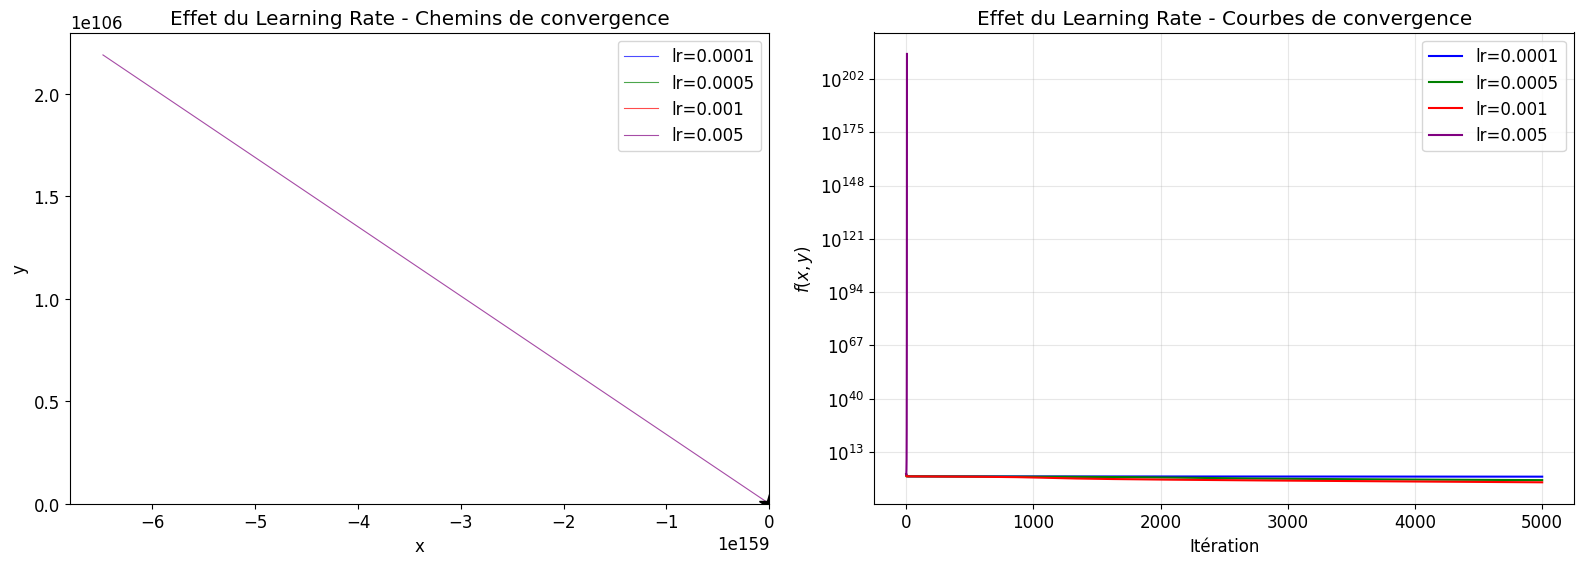

In [10]:
learning_rates = [0.0001, 0.0005, 0.001, 0.005]
colors = ['blue', 'green', 'red', 'purple']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for lr, color in zip(learning_rates, colors):
    path = batch_gradient_descent(grad_rosenbrock, x_init_rosen, learning_rate=lr, n_iterations=5000)
    path_arr = np.array(path)
    f_vals = [f_rosenbrock(p) for p in path]

    # Contour
    axes[0].plot(path_arr[:, 0], path_arr[:, 1], color=color, linewidth=0.8, alpha=0.7, label=f'lr={lr}')

    # Courbe de convergence
    axes[1].plot(f_vals, color=color, linewidth=1.5, label=f'lr={lr}')

# Contour de fond
axes[0].contour(Xr, Yr, Zr, levels=levels, cmap='gray', alpha=0.3)
axes[0].plot(1, 1, 'k*', markersize=15)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Effet du Learning Rate - Chemins de convergence')
axes[0].legend()

axes[1].set_xlabel('Itération')
axes[1].set_ylabel('$f(x, y)$')
axes[1].set_title('Effet du Learning Rate - Courbes de convergence')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Application : Classification avec Régression Logistique

On implémente une **régression logistique from scratch** optimisée par Batch Gradient Descent.

### Rappels
- Fonction sigmoïde : $\sigma(z) = \frac{1}{1 + e^{-z}}$
- Prédiction : $\hat{y} = \sigma(X \cdot w + b)$
- Fonction de coût (Binary Cross-Entropy) :
$$J(w, b) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$
- Gradients :
$$\frac{\partial J}{\partial w} = \frac{1}{N} X^T (\hat{y} - y)$$
$$\frac{\partial J}{\partial b} = \frac{1}{N} \sum (\hat{y} - y)$$

In [11]:
class LogisticRegressionBGD:
    """
    Régression Logistique optimisée par Batch Gradient Descent.
    Implémentation from scratch.
    """

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []  # Pour tracer la courbe d'entraînement

    def _sigmoid(self, z):
        """Fonction sigmoïde avec clipping pour éviter overflow"""
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _compute_loss(self, y, y_pred):
        """Binary Cross-Entropy Loss"""
        epsilon = 1e-15  # Pour éviter log(0)
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        return loss

    def fit(self, X, y):
        """
        Entraînement par Batch Gradient Descent.
        À chaque itération, on utilise TOUT le dataset pour calculer le gradient.
        """
        n_samples, n_features = X.shape

        # Initialisation des poids à zéro
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for i in range(self.n_iterations):
            # === FORWARD PASS ===
            # Calcul de la prédiction sur TOUT le dataset (Batch)
            z = X @ self.weights + self.bias
            y_pred = self._sigmoid(z)

            # === CALCUL DU COÛT ===
            loss = self._compute_loss(y, y_pred)
            self.loss_history.append(loss)

            # === CALCUL DES GRADIENTS (sur tout le dataset) ===
            error = y_pred - y  # Vecteur d'erreur (N,)
            dw = (1 / n_samples) * (X.T @ error)      # Gradient des poids
            db = (1 / n_samples) * np.sum(error)       # Gradient du biais

            # === MISE À JOUR DES PARAMÈTRES ===
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

        return self

    def predict_proba(self, X):
        """Retourne les probabilités"""
        z = X @ self.weights + self.bias
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        """Retourne les classes prédites (0 ou 1)"""
        return (self.predict_proba(X) >= threshold).astype(int)

### Génération des données

In [12]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Génération d'un dataset de classification binaire
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisation (importante pour la descente de gradient !)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train : {X_train.shape[0]} échantillons")
print(f"Test  : {X_test.shape[0]} échantillons")
print(f"Features : {X_train.shape[1]}")

Train : 800 échantillons
Test  : 200 échantillons
Features : 2


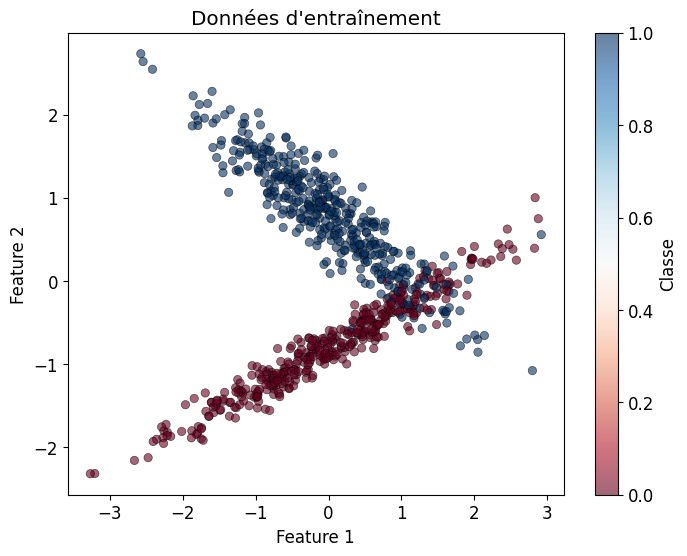

In [13]:
# Visualisation des données
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdBu', alpha=0.6, edgecolors='k', linewidth=0.5)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Données d\'entraînement')
plt.colorbar(scatter, label='Classe')
plt.show()

### Entraînement

In [14]:
# Entraînement du modèle
model_bgd = LogisticRegressionBGD(learning_rate=0.5, n_iterations=500)
model_bgd.fit(X_train, y_train)

print(f"Poids appris  : {model_bgd.weights}")
print(f"Biais appris  : {model_bgd.bias:.4f}")
print(f"Loss finale   : {model_bgd.loss_history[-1]:.6f}")

Poids appris  : [-0.58577446  4.26630914]
Biais appris  : 0.7017
Loss finale   : 0.232574


### Courbe d'entraînement (Training Loss)

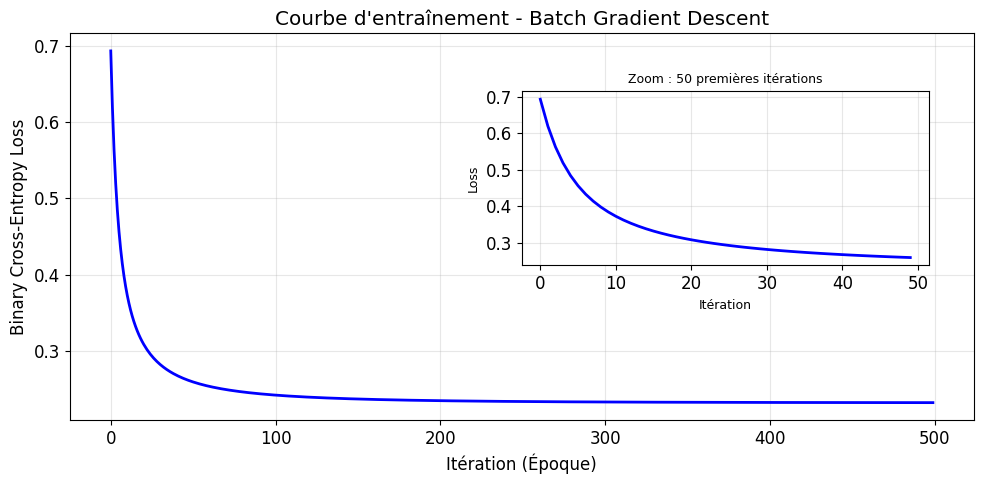

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(model_bgd.loss_history, 'b-', linewidth=2)
ax.set_xlabel('Itération (Époque)')
ax.set_ylabel('Binary Cross-Entropy Loss')
ax.set_title('Courbe d\'entraînement - Batch Gradient Descent')
ax.grid(True, alpha=0.3)

# Zoom sur les premières itérations dans un sous-plot
ax_inset = ax.inset_axes([0.5, 0.4, 0.45, 0.45])
ax_inset.plot(model_bgd.loss_history[:50], 'b-', linewidth=2)
ax_inset.set_xlabel('Itération', fontsize=9)
ax_inset.set_ylabel('Loss', fontsize=9)
ax_inset.set_title('Zoom : 50 premières itérations', fontsize=9)
ax_inset.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Frontière de décision

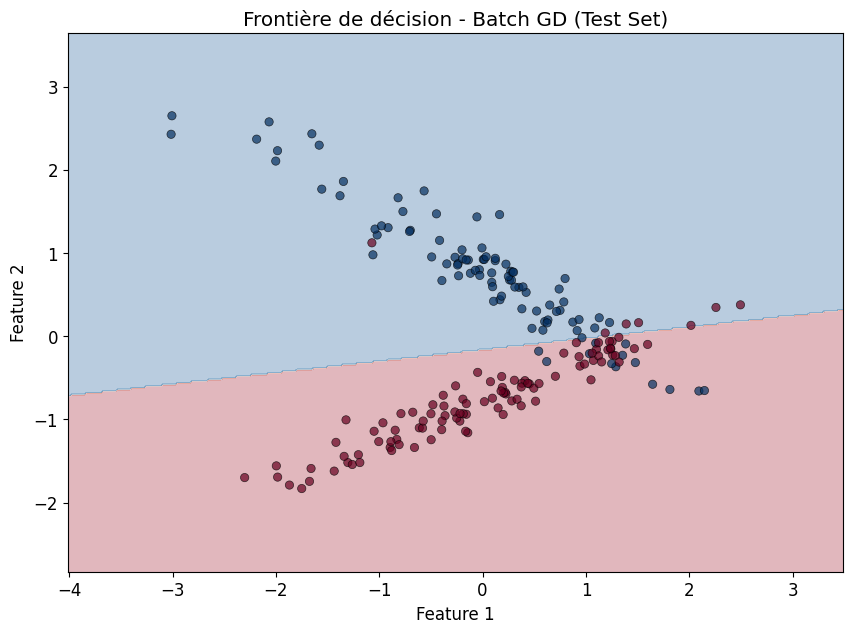

In [16]:
def plot_decision_boundary(model, X, y, title):
    """Trace la frontière de décision du modèle."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='k', linewidth=0.5, alpha=0.7)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(title)
    plt.show()

plot_decision_boundary(model_bgd, X_test, y_test, 'Frontière de décision - Batch GD (Test Set)')

## 7. Métriques d'Évaluation (from scratch)

On implémente les métriques **sans utiliser sklearn** pour bien comprendre leur calcul.

In [17]:
def confusion_matrix_manual(y_true, y_pred):
    """Calcul de la matrice de confusion."""
    tp = np.sum((y_true == 1) & (y_pred == 1))  # Vrais Positifs
    tn = np.sum((y_true == 0) & (y_pred == 0))  # Vrais Négatifs
    fp = np.sum((y_true == 0) & (y_pred == 1))  # Faux Positifs
    fn = np.sum((y_true == 1) & (y_pred == 0))  # Faux Négatifs
    return tp, tn, fp, fn

def accuracy(y_true, y_pred):
    """Accuracy = (TP + TN) / (TP + TN + FP + FN)"""
    return np.mean(y_true == y_pred)

def precision(y_true, y_pred):
    """Precision = TP / (TP + FP)"""
    tp, tn, fp, fn = confusion_matrix_manual(y_true, y_pred)
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall(y_true, y_pred):
    """Recall (Sensibilité) = TP / (TP + FN)"""
    tp, tn, fp, fn = confusion_matrix_manual(y_true, y_pred)
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def f1_score(y_true, y_pred):
    """F1-Score = 2 * (Precision * Recall) / (Precision + Recall)"""
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

In [18]:
# Prédictions sur le test set
y_pred_test = model_bgd.predict(X_test)

# Calcul des métriques
tp, tn, fp, fn = confusion_matrix_manual(y_test, y_pred_test)

print("=" * 50)
print("MÉTRIQUES D'ÉVALUATION - Batch Gradient Descent")
print("=" * 50)
print(f"\nMatrice de confusion :")
print(f"  TP = {tp}  |  FP = {fp}")
print(f"  FN = {fn}  |  TN = {tn}")
print(f"\nAccuracy  : {accuracy(y_test, y_pred_test):.4f}")
print(f"Precision : {precision(y_test, y_pred_test):.4f}")
print(f"Recall    : {recall(y_test, y_pred_test):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_test):.4f}")

MÉTRIQUES D'ÉVALUATION - Batch Gradient Descent

Matrice de confusion :
  TP = 83  |  FP = 7
  FN = 13  |  TN = 97

Accuracy  : 0.9000
Precision : 0.9222
Recall    : 0.8646
F1-Score  : 0.8925


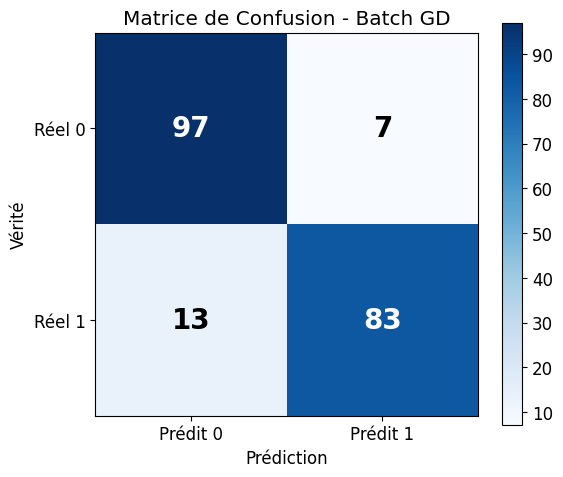

In [19]:
# Visualisation de la matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
cm = np.array([[tn, fp], [fn, tp]])
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Prédit 0', 'Prédit 1'])
ax.set_yticklabels(['Réel 0', 'Réel 1'])
ax.set_xlabel('Prédiction')
ax.set_ylabel('Vérité')
ax.set_title('Matrice de Confusion - Batch GD')

# Affichage des valeurs
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=20, fontweight='bold',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.colorbar(im)
plt.tight_layout()
plt.show()

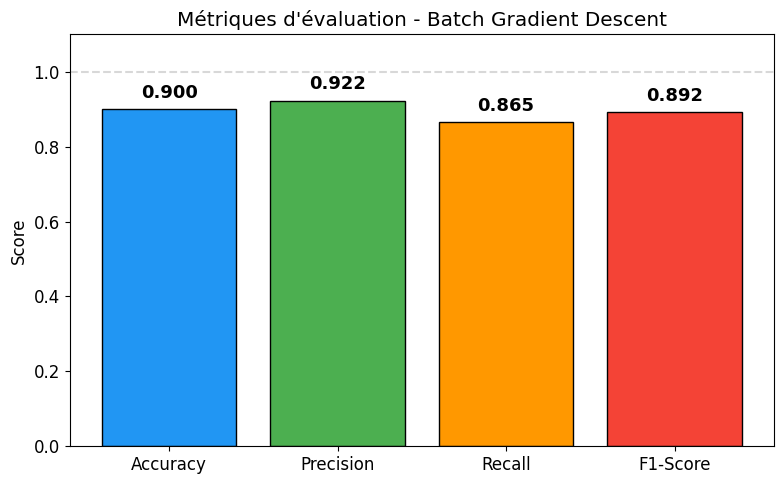

In [20]:
# Résumé visuel des métriques
metrics = {
    'Accuracy': accuracy(y_test, y_pred_test),
    'Precision': precision(y_test, y_pred_test),
    'Recall': recall(y_test, y_pred_test),
    'F1-Score': f1_score(y_test, y_pred_test)
}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(metrics.keys(), metrics.values(), color=['#2196F3', '#4CAF50', '#FF9800', '#F44336'], edgecolor='black')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Métriques d\'évaluation - Batch Gradient Descent')

# Affichage des valeurs sur les barres
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=13)

ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Conclusion

### Ce qu'on a appris :
1. Le **Batch Gradient Descent** utilise **tout le dataset** à chaque itération pour calculer le gradient
2. La convergence est **lisse et stable** (pas de bruit dans les mises à jour)
3. Le **learning rate** est un hyperparamètre crucial : trop petit = lent, trop grand = divergence
4. Sur la fonction de **Rosenbrock** (vallée étroite), le BGD peut être lent à converger
5. En classification, le BGD fonctionne bien mais peut être coûteux sur de grands datasets

### Limites :
- Pour un dataset de $N$ échantillons, chaque itération coûte $O(N)$ en calcul
- Sur de très grands datasets (millions d'exemples), c'est **trop lent**
- Solution : **SGD** (TP2) et **Mini-batch GD** (TP3)